<a href="https://colab.research.google.com/github/ian-menachery/ECON3916-Statistical-Machine-Learning/blob/main/%5BProject_1%5D_Phase_2_Data_Audit_%26_Forensics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Configure default visual settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ingest data
df = pd.read_csv('ResumeNames.csv')

# Initial data audit
print(df.shape)
display(df.head())

(4870, 28)


,rownames,name,gender,ethnicity,quality,call,city,jobs,experience,honors,...,minimum,equal,wanted,requirements,reqexp,reqcomm,reqeduc,reqcomp,reqorg,industry
0,1,Allison,female,cauc,low,no,chicago,2,6,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
1,2,Kristen,female,cauc,high,no,chicago,3,6,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
2,3,Lakisha,female,afam,low,no,chicago,1,6,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
3,4,Latonya,female,afam,high,no,chicago,4,6,no,...,5,yes,supervisor,yes,yes,no,no,yes,no,manufacturing
4,5,Carrie,female,cauc,high,no,chicago,3,22,no,...,some,yes,secretary,yes,yes,no,no,yes,yes,health/education/social services


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rownames      4870 non-null   int64 
 1   name          4870 non-null   object
 2   gender        4870 non-null   object
 3   ethnicity     4870 non-null   object
 4   quality       4870 non-null   object
 5   call          4870 non-null   object
 6   city          4870 non-null   object
 7   jobs          4870 non-null   int64 
 8   experience    4870 non-null   int64 
 9   honors        4870 non-null   object
 10  volunteer     4870 non-null   object
 11  military      4870 non-null   object
 12  holes         4870 non-null   object
 13  school        4870 non-null   object
 14  email         4870 non-null   object
 15  computer      4870 non-null   object
 16  special       4870 non-null   object
 17  college       4870 non-null   object
 18  minimum       4870 non-null   object
 19  equal 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   rownames      4870 non-null   int64 
 1   name          4870 non-null   object
 2   gender        4870 non-null   object
 3   ethnicity     4870 non-null   object
 4   quality       4870 non-null   object
 5   call          4870 non-null   object
 6   city          4870 non-null   object
 7   jobs          4870 non-null   int64 
 8   experience    4870 non-null   int64 
 9   honors        4870 non-null   object
 10  volunteer     4870 non-null   object
 11  military      4870 non-null   object
 12  holes         4870 non-null   object
 13  school        4870 non-null   object
 14  email         4870 non-null   object
 15  computer      4870 non-null   object
 16  special       4870 non-null   object
 17  college       4870 non-null   object
 18  minimum       4870 non-null   object
 19  equal 

,rownames,jobs,experience
count,4870.000000,4870.000000,4870.000000
mean,2435.500000,3.661396,7.842916
std,1405.992236,1.219126,5.044612
min,1.000000,1.000000,1.000000
25%,1218.250000,3.000000,5.000000
50%,2435.500000,4.000000,6.000000
75%,3652.750000,4.000000,9.000000
max,4870.000000,7.000000,44.000000


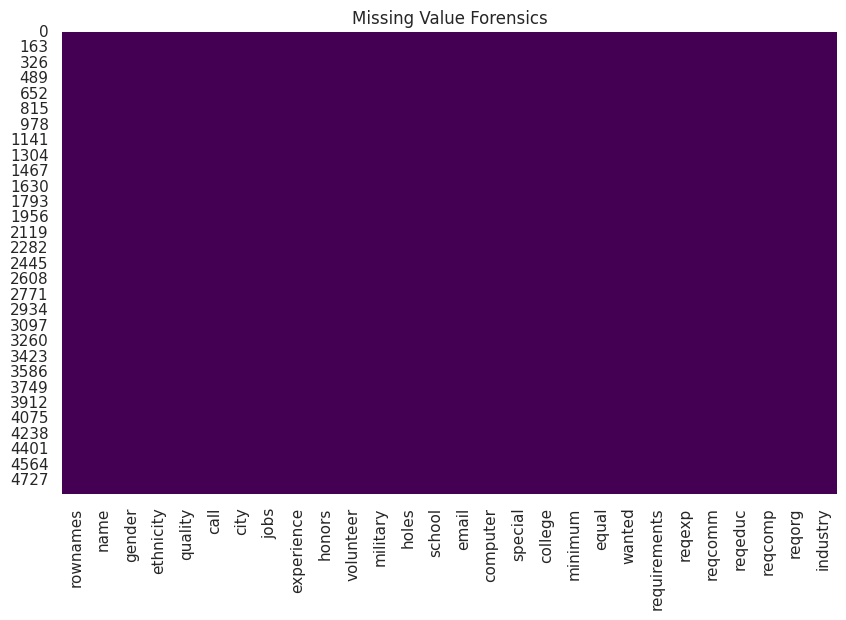

,0


In [3]:
df.info()
display(df.describe())

# Visualize missingness to evaluate MCAR vs. MAR
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Forensics')
plt.show()

# Evaluate missingness proportion
missing_pct = df.isnull().mean() * 100
display(missing_pct[missing_pct > 0])

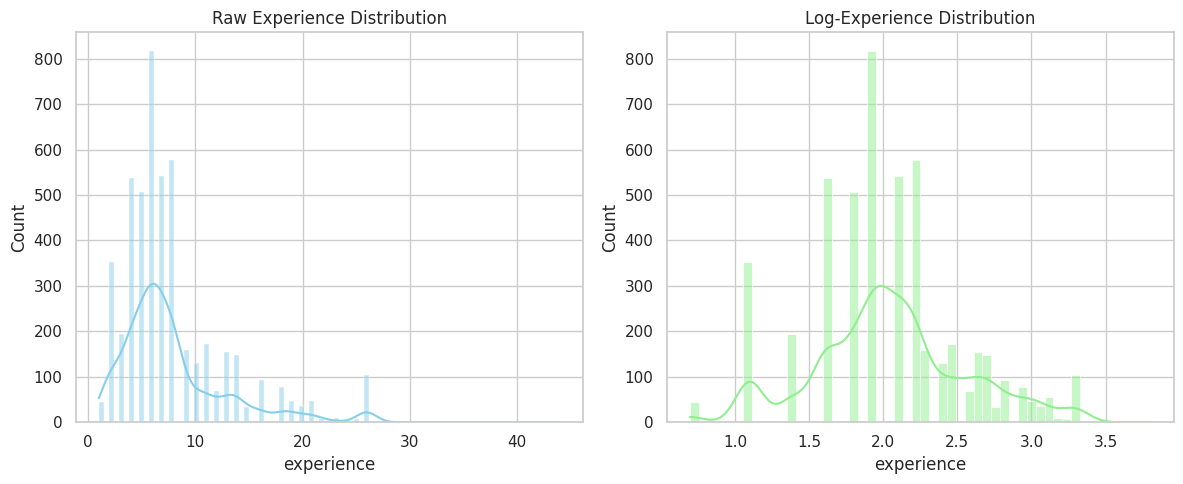

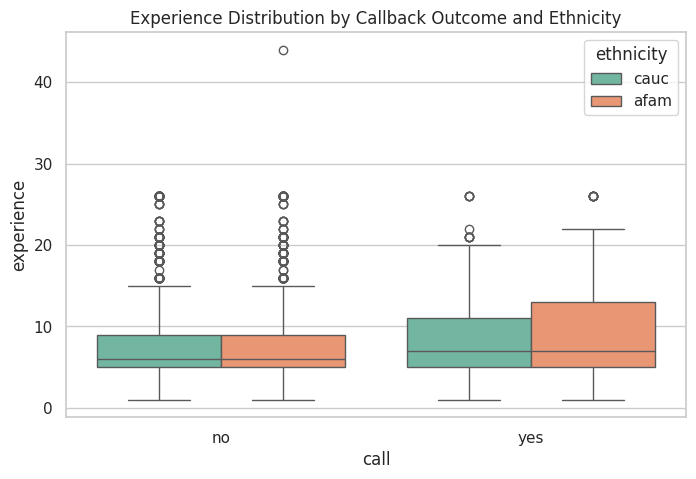

,name,ethnicity,call,experience
4,Carrie,cauc,no,22
7,Kenya,afam,no,21
53,Ebony,afam,no,19
56,Laurie,cauc,no,21
112,Anne,cauc,no,23


In [4]:
# Univariate Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['experience'], kde=True, color='skyblue')
plt.title("Raw Experience Distribution")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['experience']), kde=True, color='lightgreen')
plt.title("Log-Experience Distribution")

plt.tight_layout()
plt.show()

# Boxplot visualizing continuous experience against the binary call outcome
plt.figure(figsize=(8, 5))
sns.boxplot(x='call', y='experience', hue='ethnicity', data=df, palette='Set2')
plt.title("Experience Distribution by Callback Outcome and Ethnicity")
plt.show()

# Outlier Detection Tukey Fence
Q1 = df['experience'].quantile(0.25)
Q3 = df['experience'].quantile(0.75)
IQR = Q3 - Q1

# Establishing the lower and upper bounds
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Isolating extreme values structurally
outliers = df[(df['experience'] < lower_fence) | (df['experience'] > upper_fence)]
display(outliers[['name', 'ethnicity', 'call', 'experience']].head())